In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from utils import DATA_DIR, ROOT_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from dataloader import get_nd_array, get_slice
from download.hf import pull_predictions_from_hf

# Import scaling law code
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts'))
sys.path.append(os.path.join(f'{ROOT_DIR}/olmo-repos/olmo/scripts/scaling'))
import ladder
plt.close()

In [3]:
local_path = pull_predictions_from_hf("allenai/ladder-evals", "instances")

In [4]:
# Choose a subset of columns to save on memory
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id']
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice', 'logits_per_char_corr', 'logits_per_byte_corr'] # accuracy benchmarks
COLS += ['exact_match', 'f1'] # generation benchmarks
COLS += ['pass_at_1', 'pass_at_10'] # code benchmarks

df = pd.read_parquet(local_path, columns=COLS)
print(f'Loaded {len(df):,} instance results')

Loaded 112,840,608 instance results


In [6]:
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()
MODELS = sorted(df.index.get_level_values('model').unique().to_list())
TASKS  = sorted(df.index.get_level_values('task').unique().to_list())

In [7]:
all_ladder_models   = [model for model in MODELS if 'peteish-moreeval' in model]
data_mixes          = [model for model in MODELS if '1B-5xC' in model if 'peteish' not in model]
all_models   = sorted([model for model in MODELS if model not in data_mixes + all_ladder_models])

MODEL_1B_5xC = "peteish-moreeval-1B-5xC"

### Bradley-Terry Ranking

In [18]:
UNCOMPLETED_TASKS = [
    # Incomplete evaluations
    'agi_eval_aqua-rat:mc', 'agi_eval_gaokao-english:mc', 'agi_eval_logiqa-en:mc', 'agi_eval_lsat-ar:mc', 'agi_eval_lsat-lr:mc', 'agi_eval_lsat-rc:mc', 'agi_eval_sat-en-without-passage:mc', 'agi_eval_sat-en:mc', 'agi_eval_sat-math:mc', 
    'aime', 
    'autobencher:mc', 
    'bbh_boolean_expressions', 'bbh_causal_judgement', 'bbh_date_understanding', 'bbh_disambiguation_qa', 'bbh_dyck_languages', 'bbh_formal_fallacies', 'bbh_geometric_shapes', 'bbh_hyperbaton', 'bbh_logical_deduction_five_objects', 'bbh_logical_deduction_seven_objects', 'bbh_logical_deduction_three_objects', 'bbh_movie_recommendation', 'bbh_multistep_arithmetic_two', 'bbh_navigate', 'bbh_object_counting', 'bbh_penguins_in_a_table', 'bbh_reasoning_about_colored_objects', 'bbh_ruin_names', 'bbh_salient_translation_error_detection', 'bbh_snarks', 'bbh_sports_understanding', 'bbh_temporal_sequences', 'bbh_tracking_shuffled_objects_five_objects', 'bbh_tracking_shuffled_objects_seven_objects', 'bbh_tracking_shuffled_objects_three_objects', 'bbh_web_of_lies', 'bbh_word_sorting', 
    'copycolors:mc', 
    'coqa', 
    'mbpp', 
    'mbppplus', 

    # broken?
    'deepmind_math_large', 'autobencher', 'gsm_plus'
]

task_name = ["arc_challenge"]
# task_name = ["arc_challenge", "arc_easy"]
# task_name = [task for task in TASKS if 'mmlu' in task and ':' not in task and 'pro' not in task]
# task_name = [task for task in TASKS if 'mmlu' in task and ':' not in task and 'pro' not in task and 'moral_scenarios' not in task]
# task_name = [task for task in TASKS if ':' not in task and 'paloma' not in task and 'moral_scenarios' not in task]

task_name = [t for t in task_name if t not in UNCOMPLETED_TASKS] # tasks that have at least one model not evaluated

In [19]:
model_names, scores = get_nd_array(
    df,
    col=["model"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task=task_name,
    model=all_models,
    sorted=True
)

print(f'Results on {len(model_names)} models:')
print(scores)
print(scores.shape)

Results on 37 models:
[[1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]
 ...
 [1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]]
(37, 105880)


In [20]:
step_names, step_scores = get_nd_array(
    df,
    col=["step"], # the dimensions of the array
    metric="acc_per_char", # the entries of the array
    task=task_name,
    model=MODEL_1B_5xC,
    sorted=False
)

print(f'Results on {len(step_names)} models:')
print(step_scores)
print(step_scores.shape)

Results on 164 models:
[[1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]
 ...
 [1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 1. 1. 1.]]
(164, 105880)


In [24]:
# Filter any instances which have 'nan' values for either set of models
valid_cols_mask = ~np.isnan(scores).any(axis=0) & ~np.isnan(step_scores).any(axis=0)
scores      = scores[:, valid_cols_mask]
step_scores = step_scores[:, valid_cols_mask]

In [25]:
assert np.isnan(scores).sum() == 0, 'Some scores do not exist!'
assert np.isnan(step_scores).sum() == 0, 'Some scores do not exist!'
assert scores.shape[1] == step_scores.shape[1], (scores.shape, step_scores.shape)

Total variation of ['arc_challenge', 'arc_easy', 'boolq', 'codex_humaneval', 'codex_humanevalplus', 'csqa', 'drop', 'gpqa', 'gsm8k', 'gsm_symbolic_main', 'gsm_symbolic_p1', 'gsm_symbolic_p2', 'hellaswag', 'jeopardy', 'medmcqa', 'minerva_math_500', 'minerva_math_algebra', 'minerva_math_counting_and_probability', 'minerva_math_geometry', 'minerva_math_intermediate_algebra', 'minerva_math_number_theory', 'minerva_math_prealgebra', 'minerva_math_precalculus', 'mmlu_abstract_algebra', 'mmlu_anatomy', 'mmlu_astronomy', 'mmlu_business_ethics', 'mmlu_clinical_knowledge', 'mmlu_college_biology', 'mmlu_college_chemistry', 'mmlu_college_computer_science', 'mmlu_college_mathematics', 'mmlu_college_medicine', 'mmlu_college_physics', 'mmlu_computer_security', 'mmlu_conceptual_physics', 'mmlu_econometrics', 'mmlu_electrical_engineering', 'mmlu_elementary_mathematics', 'mmlu_formal_logic', 'mmlu_global_facts', 'mmlu_high_school_biology', 'mmlu_high_school_chemistry', 'mmlu_high_school_computer_science

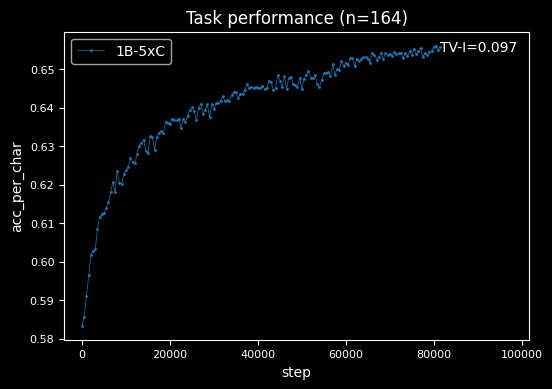

In [27]:
from stats import calculate_and_plot_total_variation

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

acc = step_scores.mean(axis=1)
tv = calculate_and_plot_total_variation(
    ax=axes[0, 0],
    model_name="1B-5xC", 
    x=step_names, y=acc,
    metric="acc_per_char",
    title=f'Task performance (n={step_scores.shape[0]})'
)
print(f'Total variation of {task_name} training curve: {tv}')

### Fit Bradley-Terry Model

In [28]:
from irt import bradley_terry_scores

train_scores, test_scores = bradley_terry_scores(train_scores=scores, test_scores=step_scores)

Computing test scores: 100%|██████████| 164/164 [00:08<00:00, 19.32it/s]


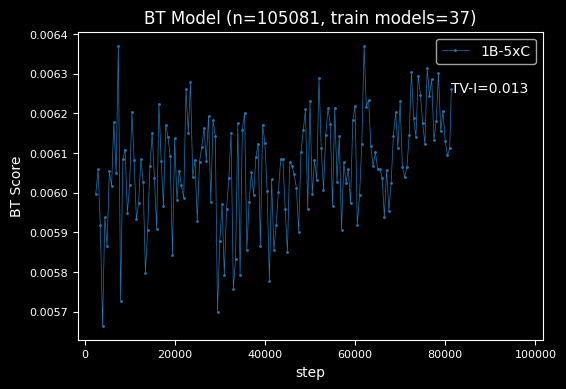

In [29]:
from plot import plot_training
from stats import calculate_and_plot_total_variation

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

_ = calculate_and_plot_total_variation(
    ax=axes[0, 0], 
    model_name="1B-5xC",
    # x=step_names, y=test_scores,
    x=step_names[5:], y=test_scores[5:],
    metric="BT Score", 
    title=f'BT Model (n={scores.shape[1]}, train models={scores.shape[0]})'
)

### Filter Test Instances

/Users/dhei/ai2/new-evals/analysis/irt.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearsonr(step_scores[:, i], total_scores)[0]


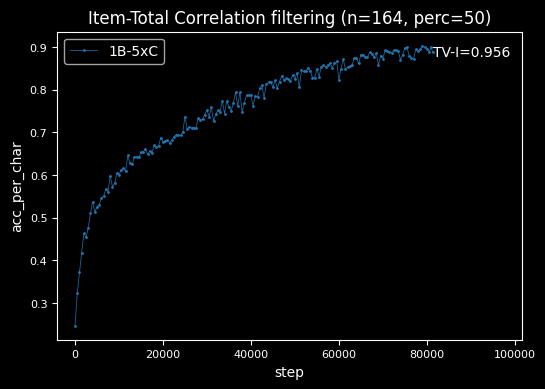

In [30]:
from irt import itc_filtering

fig, axes = plt.subplots(1, 1, figsize=(6*1, 4), squeeze=False)

PERCENTILE = 50

filtered_scores = itc_filtering(step_scores, percentile=50)

acc = filtered_scores.mean(axis=1)

tv = calculate_and_plot_total_variation(
    ax=axes[0, 0],
    model_name="1B-5xC", 
    x=step_names, y=acc,
    metric="acc_per_char",
    title=f'Item-Total Correlation filtering (n={filtered_scores.shape[0]}, perc={PERCENTILE})'
)

100%|██████████| 19/19 [00:07<00:00,  2.49it/s]


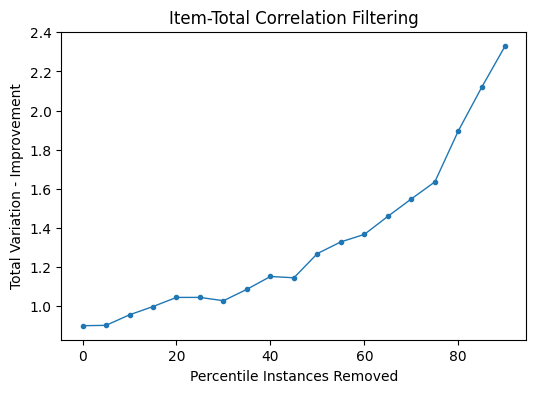

In [60]:
# Calculate TV for different percentile thresholds
percentiles = np.arange(0, 91, 5)
tvs = []
for p in tqdm(percentiles):
    filtered_scores = itc_filtering(step_scores, percentile=p)
    acc = filtered_scores.mean(axis=1)
    tv = calculate_and_plot_total_variation(
        x=step_names, y=acc,
        metric="acc_per_char",
    )
    tvs.append(tv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(percentiles, tvs, '-o', linewidth=1, markersize=3)
ax.set_xlabel('Percentile Instances Removed')
ax.set_ylabel('Total Variation - Improvement')
ax.set_title('Item-Total Correlation Filtering')
plt.show()

100%|██████████| 19/19 [00:00<00:00, 1480.87it/s]


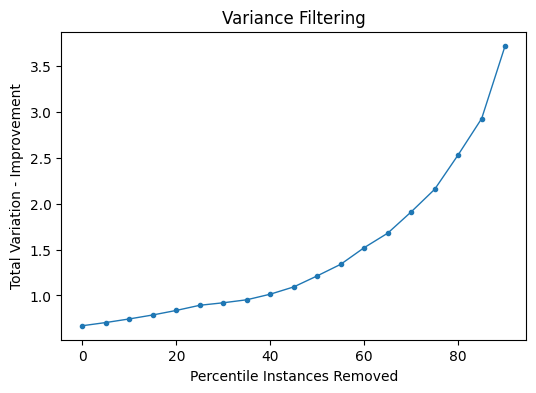

In [ ]:
from irt import variance_filtering

# Calculate TV for different percentile thresholds
percentiles = np.arange(0, 91, 5)
tvs = []
for p in tqdm(percentiles):
    filtered_scores = variance_filtering(step_scores, percentile=p)
    acc = filtered_scores.mean(axis=1)
    tv = calculate_and_plot_total_variation(
        x=step_names, y=acc,
        metric="acc_per_char",
    )
    tvs.append(tv)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(percentiles, tvs, '-o', linewidth=1, markersize=3)
ax.set_xlabel('Percentile Instances Removed')
ax.set_ylabel('Total Variation - Improvement')
ax.set_title('Variance Filtering')
plt.show()